# Exercise 4: Resampling Methods
Clara Hardes, 01.10.2026

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from scipy.optimize import minimize
from scipy.special import factorial

In [2]:
df = pd.read_csv(r"bern02\Labs\pollution_cleaneddata.csv")

In [3]:
df.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


## Validation Set Approach

In [ ]:
def validation_set(df,seed=42):
    '''
    Split the data in two equally sized sets
    '''
    train, test = train_test_split(
        df,
        test_size=0.5,
        random_state=seed
    )

    X_train = train[["JULT"]]
    y_train = train["MORT"]

    X_test = test[["JULT"]]
    y_test = test["MORT"]
    return X_train,y_train,X_test,y_test


In [ ]:
def polynomial_mse(X_train,y_train,X_test,y_test,degree_range=range(1,5),plot=False):
    '''
    Function to fit a polynomial regression model with changing degrees and possibility to plot

    input:
        X_train (pd.DataFrame): training data input
        y_train (pd.DataFrame): training data labels
        X_test (pd.DataFrame): test data input
        y_test (pd.DataFrame): test data labels
        degree_range (range): fit different models over specified range of degrees
        plot (bool): plot the models and MSE

    return:
        results (pd.DataFrame): MSE results for training and test data and degrees

    '''

    
    results = []

    if plot:
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        axes = axes.ravel()


    for degree in degree_range:

        #prepare the model 
        poly = PolynomialFeatures(degree=degree)

        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # fit the model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        train_pred = model.predict(X_train_poly)
        test_pred = model.predict(X_test_poly)

        results.append({
            "degree": degree,
            "train_mse": mean_squared_error(y_train, train_pred),
            "test_mse": mean_squared_error(y_test, test_pred)
        })

        if plot:

            x_curve = np.linspace(
                X_train["JULT"].min(),
                X_train["JULT"].max(),
                200
            ).reshape(-1, 1)

            y_curve = model.predict(
                poly.transform(x_curve)
            )

            axes[degree - 1].scatter(
                X_train["JULT"],
                y_train,
                label="Training data"
            )

            axes[degree - 1].scatter(
                X_test["JULT"],
                y_test,
                label="Testing data"
            )

            axes[degree - 1].plot(
                x_curve,
                y_curve,
                label=f"Degree {degree}"
            )

            axes[degree - 1].set_xlabel("Average July temperature (°F)")
            axes[degree - 1].set_ylabel("Mortality")
            axes[degree - 1].set_title(f"Polynomial degree {degree}")
            axes[degree - 1].legend()

    results = pd.DataFrame(results)

    if plot:

        axes[4].plot(
            results["degree"],
            results["train_mse"],
            marker="o",
            label="Training MSE"
        )

        axes[4].plot(
            results["degree"],
            results["test_mse"],
            marker="o",
            label="Testing MSE"
        )

        axes[4].set_xlabel("Polynomial degree")
        axes[4].set_ylabel("Mean Squared Error")
        axes[4].set_title("MSE by polynomial degree")
        axes[4].set_xticks([1, 2, 3, 4])
        axes[4].legend()

        axes[5].axis("off")

        plt.tight_layout()
        plt.show()

    return results

### Plot MSE over different degrees

c:\Users\clara\anaconda3\envs\cnn_course\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\clara\anaconda3\envs\cnn_course\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\clara\anaconda3\envs\cnn_course\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\clara\anaconda3\envs\cnn_course\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


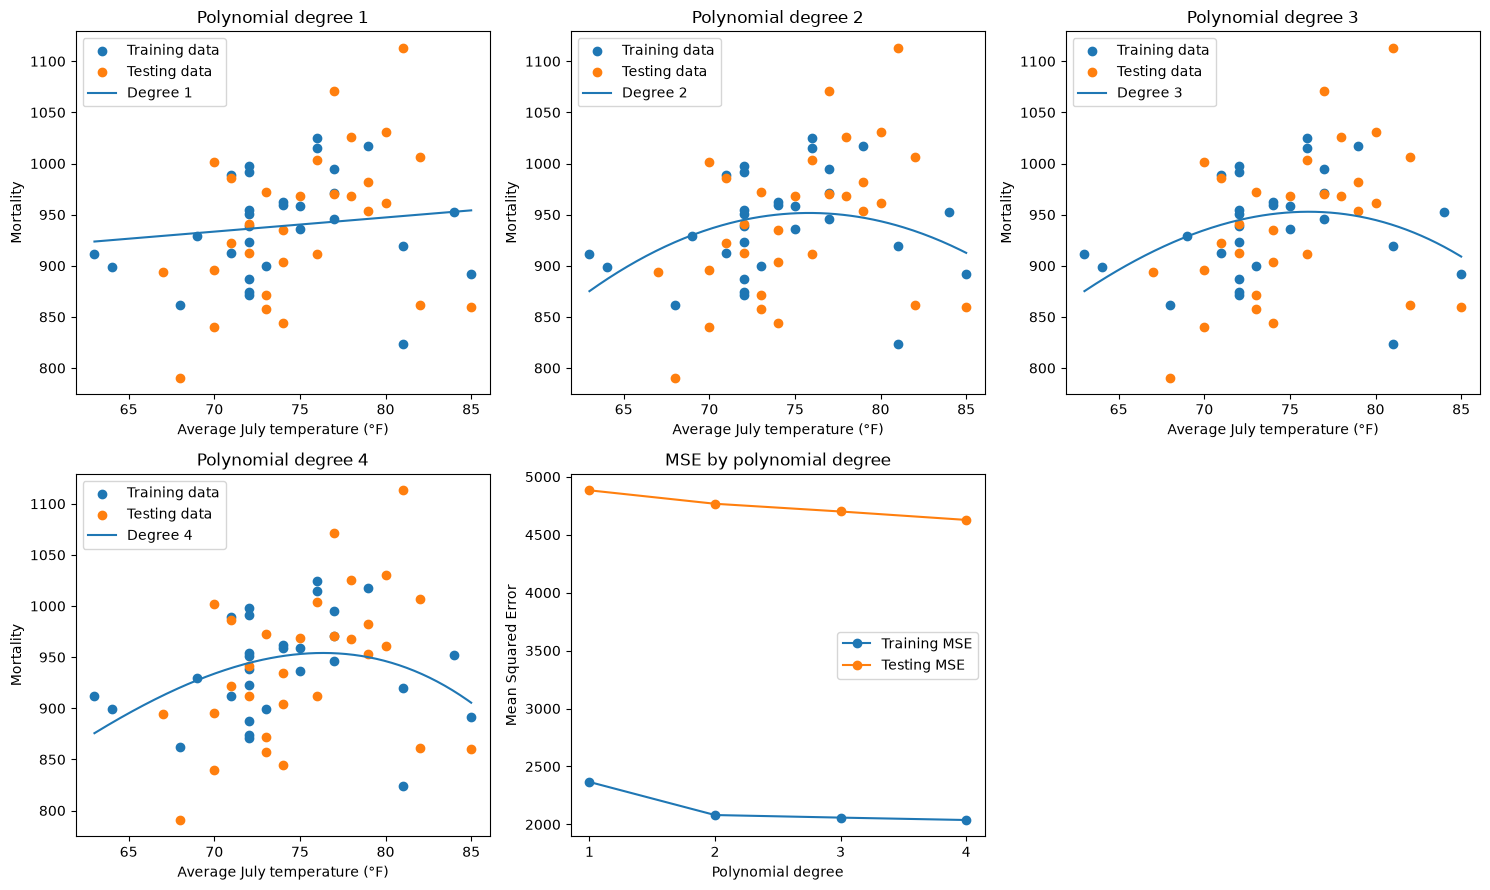

In [ ]:
# prepare data and build models + plot
X_train,y_train,X_test,y_test = validation_set(df)
results = polynomial_mse(X_train,y_train,X_test,y_test, plot=True)

I would recommend taking degree 4 since the mean square error is the lowest for training and test data.

### Change random seed + comparison 

In [61]:
all_results = pd.concat(
    [polynomial_mse(*validation_set(df, seed)).assign(seed=seed) for seed in range(10)],
    ignore_index=True
)

print(all_results)

    degree    train_mse     test_mse  seed
0        1  3837.186042  3202.000744     0
1        2  3667.541440  2874.583869     0
2        3  3634.029171  2821.110660     0
3        4  3598.081549  2765.436687     0
4        1  2545.297540  5040.756601     1
5        2  1725.969873  6264.876170     1
6        3  1699.517207  5848.947351     1
7        4  1674.595113  5506.432933     1
8        1  3741.839939  3478.233759     2
9        2  2303.107520  6425.207260     2
10       3  2278.884835  5915.792389     2
11       4  2262.494384  5462.582389     2
12       1  3503.976595  3667.911949     3
13       2  3213.486241  3508.538872     3
14       3  3179.265168  3462.713780     3
15       4  3144.670051  3412.668122     3
16       1  3370.659741  4017.191740     4
17       2  3355.017044  4456.842315     4
18       3  3356.829247  4442.716460     4
19       4  3357.521714  4410.195439     4
20       1  4489.139187  2563.018524     5
21       2  4154.468428  2407.977929     5
22       3 

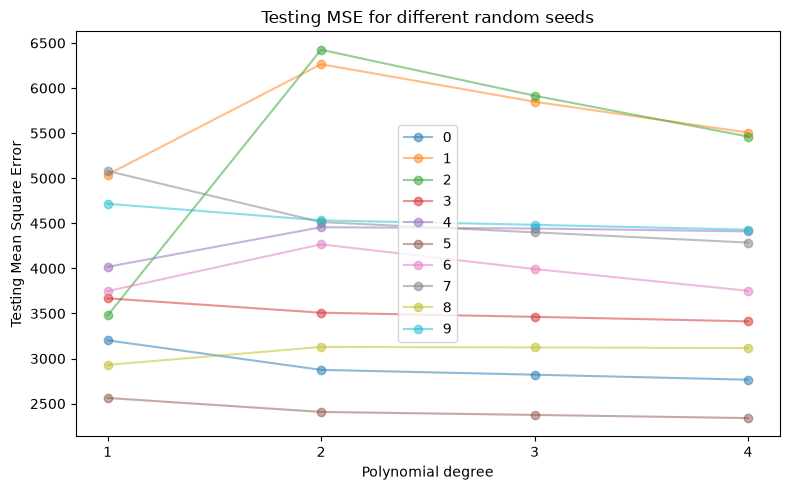

In [69]:
plt.figure(figsize=(8, 5))

for seed in range(10):

    subset = all_results[all_results["seed"] == seed]

    plt.plot(
        subset["degree"],
        subset["test_mse"],
        label = seed,
        marker="o",
        alpha=0.5
    )

plt.legend()
plt.xlabel("Polynomial degree")
plt.ylabel("Testing Mean Square Error")
plt.xticks([1, 2, 3, 4])
plt.title("Testing MSE for different random seeds")
plt.tight_layout()
plt.show()

There are different results for different seeds, thats because the training and test data is split up differently depending on the seed. If the model is fitted on different datapoints as training data, the resulting models differ. Additionally the MSE in test data is differing since the split sometimes contains a lot of datapoints close to the polynomial model and sometimes more far away datapoints.

## K-fold cross-validation

In [ ]:
def cross_validation_mse(df, degree=4, k=3, seed=5):

    '''
    Splits data in k-folds and applies polynomial_mse on them 
    '''

    X = df[["JULT"]]
    y = df["MORT"]

    kfold = KFold(
        n_splits=k,
        shuffle=True,
        random_state=seed
    )

    all_results = []

    for k, (train_idx, test_idx) in enumerate(kfold.split(X), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        results = polynomial_mse(
            X_train, y_train, X_test, y_test,
            degree_range=range(degree, degree+1)
        ).assign(k=k)

        all_results.append(results)

    all_results = pd.concat(all_results, ignore_index=True)
    return all_results

In [109]:
# apply with polynomial degree 4 and K=3
results = cross_validation_mse(
    df,
    degree=4,
    k=3,
    seed=42
)

print(results)


   degree    train_mse     test_mse  k
0       4  2262.968379  5263.621136  1
1       4  3250.551815  3326.438249  2
2       4  3648.391131  3085.212306  3


### Compare different seeds

In [90]:
k_fold_results = pd.concat(
    [cross_validation_mse(df,seed=seed).assign(seed=seed) for seed in range(10)],
    ignore_index=True
)

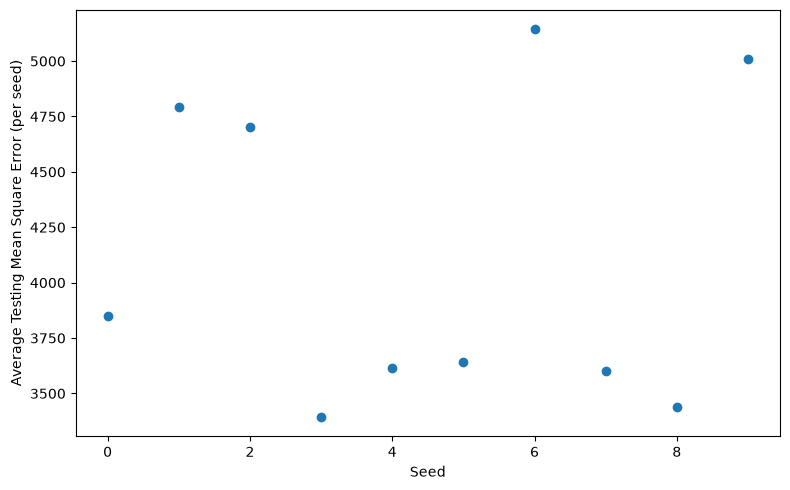

In [99]:
plt.figure(figsize=(8, 5))
plt.scatter(range(10),k_fold_results.groupby("seed")["test_mse"].mean())
plt.xlabel("Seed")
plt.ylabel("Average Testing Mean Square Error (per seed)")
plt.tight_layout()
plt.show()

Again the mean squared error is differing per seed (in this case average MSE across the three folds).

## Bootstrap

In [106]:
df_bird = pd.read_csv(r"bern02\Labs\bird_count.csv")
#adjust years (new_year = old_year - min(year), so that the exponential is not exploding
df_bird['yr_num'] = [yr - min(df_bird['yr']) for yr in df_bird['yr']]

In [107]:
#select adjusted year values for x and bird counts for y
x = df_bird['yr_num']
y = df_bird['count']


def objective(param,x,y): #x=year,y=count
    '''
    objective function: implements the log likelyhood function for Poisson GLM and returns the neg(log_likelihood) 
    --> so that scipy.optimize.minimize can be used (although we want to maximize the function)
    '''
    b0,b1 = param #the parameters to optimize
    log_lam = b0 + b1*x
    lam = np.exp(log_lam)
    return -(np.sum(-(lam) + y*(log_lam) - np.log(factorial(y))))



In [114]:
B = 1000
bootstrap_slopes = []

for i in range(B):

    # sample observations with replacement
    indices = np.random.choice(len(x), size=len(x), replace=True)

    x_boot = x.iloc[indices]
    y_boot = y.iloc[indices]

    # fit Poisson model to bootstrap sample
    result_boot = minimize(
        objective,
        x0=[0, 0],
        args=(x_boot, y_boot)
    )

    # save estimated slope
    bootstrap_slopes.append(result_boot.x[1])

# bootstrap standard error
se_bootstrap = np.std(bootstrap_slopes, ddof=1)

print("Bootstrap standard deviation:", se_bootstrap)

Bootstrap standard deviation: 0.03454292681571996


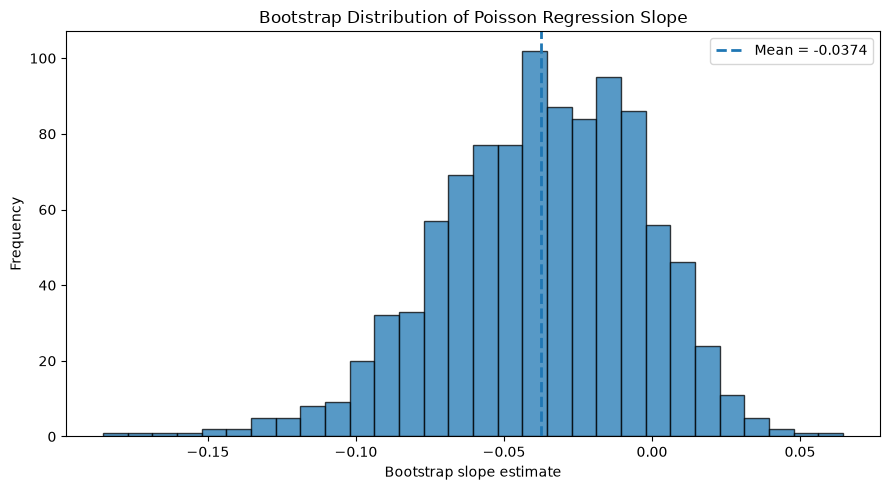

In [115]:
plt.figure(figsize=(9, 5))

plt.hist(
    bootstrap_slopes,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    np.mean(bootstrap_slopes),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(bootstrap_slopes):.4f}"
)

plt.xlabel("Bootstrap slope estimate")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Poisson Regression Slope")
plt.legend()
plt.tight_layout()
plt.show()

I get ~0.0345 as standard deviation.